In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [10]:
data=load_diabetes()

In [11]:
X=data.data
y=data.target

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [13]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [14]:
L.fit(X_train,y_train)

LinearRegression()

In [17]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [19]:
y_pred= L.predict(X_test)

In [24]:
from sklearn.metrics import r2_score,mean_squared_error
print('r2',r2_score(y_test,y_pred))
print('rmse',np.sqrt(mean_squared_error(y_test,y_pred)))


r2 0.5188113124539249
rmse 48.72713760953253


now using ridge regression

In [26]:
from sklearn.linear_model import Ridge
r=Ridge(alpha=0.0001)

In [27]:
r.fit(X_train,y_train)

Ridge(alpha=0.0001)

In [28]:
print(r.coef_)
print(r.intercept_)

[  23.51763492 -247.31766656  492.28244914  329.3317593  -957.46324421
  562.90310325  176.71070198  254.47033329  789.10867561   89.41375823]
152.13492030963658


In [30]:
y_pred=r.predict(X_test)
print('r2',r2_score(y_test,y_pred))
print('rmse',np.sqrt(mean_squared_error(y_test,y_pred)))

r2 0.5189732635884949
rmse 48.71893700181956


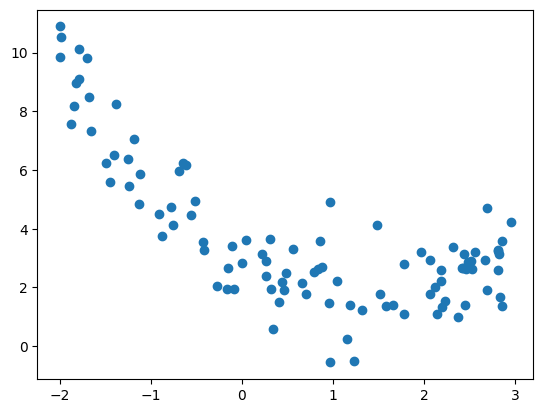

In [31]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()


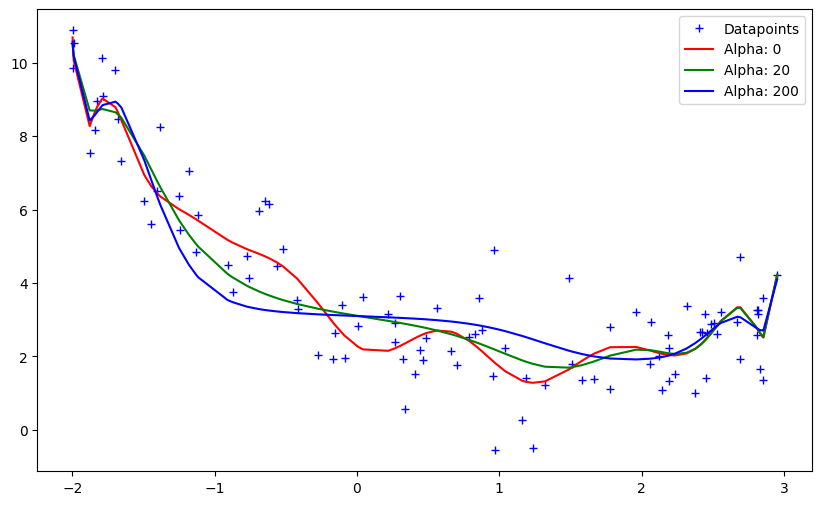

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()